# Empirical Application: Hillstrom E-Mail Analytics
https://www.kaggle.com/datasets/bofulee/kevin-hillstrom-minethatdata-e-mailanalytics

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency, pearsonr
import empirical_methods as em

In [10]:
df_raw = pd.read_csv("data/empirical_data.csv")
print("Shape:", df_raw.shape)
print()
print("dtypes:")
print(df_raw.dtypes)

Shape: (64000, 12)

dtypes:
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
dtype: object


In [11]:
cat_cols = ['history_segment', 'zip_code', 'channel', 'segment']
for col in cat_cols:
    vc = df_raw[col].value_counts()
    print(f"--- {col} ---")
    print(vc.to_string())
    print()

--- history_segment ---
history_segment
1) $0 - $100        22970
2) $100 - $200      14254
3) $200 - $350      12289
4) $350 - $500       6409
5) $500 - $750       4911
6) $750 - $1,000     1859
7) $1,000 +          1308

--- zip_code ---
zip_code
Surburban    28776
Urban        25661
Rural         9563

--- channel ---
channel
Web             28217
Phone           28021
Multichannel     7762

--- segment ---
segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306



## Data preparation

In [23]:
# Main analysis: Mens E-Mail vs No E-Mail
df_mens_treat = df_raw[df_raw['segment'] == 'Mens E-Mail'].copy()
df_no_email   = df_raw[df_raw['segment'] == 'No E-Mail'].copy()

print(f"Mens E-Mail (treatment):  {len(df_mens_treat):,} rows")
print(f"No E-Mail (no treatment): {len(df_no_email):,} rows")

Mens E-Mail (treatment):  21,307 rows
No E-Mail (no treatment): 21,306 rows


In [13]:
# Calibration split from No E-Mail (seed=42, 20%)
calib = df_no_email.sample(frac=0.2, random_state=42)
df_analysis_control = df_no_email.drop(calib.index).copy()

print(f"Calibration set size: {len(calib):,}")

c_lower = float(np.nanquantile(calib['spend'], 0.003))
c_upper = float(np.nanquantile(calib['spend'], 0.997))
print(f"Winsorization bounds from calibration: [{c_lower:.4f}, {c_upper:.4f}]")

# Build analysis DataFrame: analysis control + all Mens treatment
df_mens = pd.concat([
    df_analysis_control.assign(is_treatment=False),
    df_mens_treat.assign(is_treatment=True)
], ignore_index=True)

n_ctrl = (df_mens['is_treatment'] == False).sum()
n_trt  = (df_mens['is_treatment'] == True).sum()
print(f"\nMens analysis sample:")
print(f"  Control (analysis):  {n_ctrl:,}")
print(f"  Treatment (Mens):    {n_trt:,}")
print(f"  Total:               {len(df_mens):,}")


Calibration set size: 4,261
Winsorization bounds from calibration: [0.0000, 90.7812]

Mens analysis sample:
  Control (analysis):  17,045
  Treatment (Mens):    21,307
  Total:               38,352


In [14]:
# Balance check: pre-treatment variables
ctrl_m = df_mens[df_mens['is_treatment'] == False]
trt_m  = df_mens[df_mens['is_treatment'] == True]

balance_rows = []

# Continuous variables: t-test
for var in ['history', 'recency']:
    c_vals = ctrl_m[var].dropna()
    t_vals = trt_m[var].dropna()
    stat, pval = ttest_ind(c_vals, t_vals, equal_var=False)
    balance_rows.append({
        'Variable': var,
        'Control mean': c_vals.mean(),
        'Treatment mean': t_vals.mean(),
        'Test': 'Welch t',
        'p-value': pval,
    })

# Binary variables: t-test (difference in proportions)
for var in ['newbie', 'mens', 'womens']:
    c_vals = ctrl_m[var].dropna()
    t_vals = trt_m[var].dropna()
    stat, pval = ttest_ind(c_vals, t_vals, equal_var=False)
    balance_rows.append({
        'Variable': var,
        'Control mean': c_vals.mean(),
        'Treatment mean': t_vals.mean(),
        'Test': 'Welch t',
        'p-value': pval,
    })

# Categorical: chi-square
for var in ['channel', 'zip_code']:
    ct = pd.crosstab(df_mens['is_treatment'], df_mens[var])
    chi2, pval, dof, _ = chi2_contingency(ct)
    balance_rows.append({
        'Variable': var,
        'Control mean': '(categorical)',
        'Treatment mean': '(categorical)',
        'Test': 'Chi-square',
        'p-value': pval,
    })

bal_df = pd.DataFrame(balance_rows)
bal_df['p-value'] = bal_df['p-value'].apply(lambda x: f"{x:.4f}" if isinstance(x, float) else x)
print("Balance check — Mens E-Mail vs Analysis Control")
print(bal_df.to_string(index=False))


Balance check — Mens E-Mail vs Analysis Control
Variable  Control mean Treatment mean       Test p-value
 history    240.367037     242.835931    Welch t  0.3503
 recency      5.778469       5.773642    Welch t  0.8934
  newbie      0.500029       0.501525    Welch t  0.7709
    mens      0.552244       0.550946    Welch t  0.7995
  womens      0.548255       0.551415    Welch t  0.5365
 channel (categorical)  (categorical) Chi-square  0.6024
zip_code (categorical)  (categorical) Chi-square  0.2346


## Descriptive statistics

In [15]:
def desc_stats(grp_df, label):
    spend = grp_df['spend']
    return {
        'Group': label,
        'n': len(grp_df),
        'Mean spend': spend.mean(),
        'Median spend': spend.median(),
        'Std spend': spend.std(),
        'Max spend': spend.max(),
        '% zeros': (spend == 0).mean() * 100,
        'Visit rate (%)': grp_df['visit'].mean() * 100,
        'Conv rate (%)': grp_df['conversion'].mean() * 100,
        'Mean history': grp_df['history'].mean(),
        'Std history': grp_df['history'].std(),
    }

desc_rows_mens = [
    desc_stats(ctrl_m, 'Control (No E-Mail)'),
    desc_stats(trt_m, 'Treatment (Mens E-Mail)'),
]
desc_df_mens = pd.DataFrame(desc_rows_mens).set_index('Group').T
print("Descriptive statistics — Mens analysis sample")
print(desc_df_mens.to_string())

Descriptive statistics — Mens analysis sample
Group           Control (No E-Mail)  Treatment (Mens E-Mail)
n                      17045.000000             21307.000000
Mean spend                 0.637544                 1.422617
Median spend               0.000000                 0.000000
Std spend                 11.533335                17.754205
Max spend                499.000000               499.000000
% zeros                   99.448519                98.746891
Visit rate (%)            10.636550                18.275684
Conv rate (%)              0.551481                 1.253109
Mean history             240.367037               242.835931
Std history              254.647868               260.355685


In [ ]:
print("Correlation: history vs spend")
print()
r_ctrl, p_ctrl = pearsonr(ctrl_m['history'], ctrl_m['spend'])
r_trt,  p_trt  = pearsonr(trt_m['history'],  trt_m['spend'])
r_pool, p_pool = pearsonr(df_mens['history'], df_mens['spend'])

print(f"  Control:   r = {r_ctrl:.4f},  p = {p_ctrl:.4e}")
print(f"  Treatment: r = {r_trt:.4f},  p = {p_trt:.4e}")
print(f"  Pooled:    r = {r_pool:.4f},  p = {p_pool:.4e}")

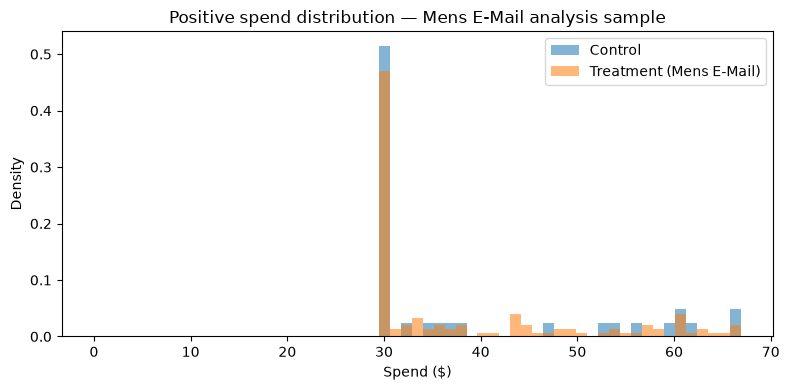

In [24]:
# Positive spends
ctrl_pos = ctrl_m.loc[ctrl_m['spend'] > 0, 'spend']
trt_pos  = trt_m.loc[trt_m['spend']  > 0, 'spend']
fig2, ax2 = plt.subplots(figsize=(8, 4))
bins2 = np.linspace(0, df_mens['spend'].quantile(0.995), 60)
ax2.hist(ctrl_pos, bins=bins2, alpha=0.55, label='Control', density=True)
ax2.hist(trt_pos,  bins=bins2, alpha=0.55, label='Treatment (Mens E-Mail)', density=True)
ax2.set_xlabel('Spend ($)')
ax2.set_ylabel('Density')
ax2.set_title('Positive spend distribution — Mens E-Mail analysis sample')
ax2.legend()
fig2.tight_layout()
plt.show()

## Results: Mens E-Mail vs No E-Mail

In [18]:
# Extract arrays
ctrl_spend  = ctrl_m['spend'].values.astype(float)
trt_spend   = trt_m['spend'].values.astype(float)
ctrl_hist   = ctrl_m['history'].values.astype(float)
trt_hist    = trt_m['history'].values.astype(float)
ctrl_chan   = ctrl_m['channel'].values
trt_chan    = trt_m['channel'].values

mens_results = {}

mens_results['Welch t-test'] = em.welch(ctrl_spend, trt_spend)

mens_results['CUPED'] = em.cuped_method(
    ctrl_spend, trt_spend, ctrl_hist, trt_hist)

mens_results['Stratification'] = em.stratification_method(
    ctrl_spend, trt_spend, ctrl_chan, trt_chan)

mens_results['Winsorization'] = em.winsorize_method(
    ctrl_spend, trt_spend, c_lower, c_upper)

mens_results['Winsorization + CUPED'] = em.winsorized_cuped_method(
    ctrl_spend, trt_spend, ctrl_hist, trt_hist, c_lower, c_upper)

mens_results['Winsorization + Stratification'] = em.winsorized_stratification_method(
    ctrl_spend, trt_spend, ctrl_chan, trt_chan, c_lower, c_upper)

mens_results['Stratification + CUPED'] = em.stratified_cuped_method(
    ctrl_spend, trt_spend, ctrl_hist, trt_hist, ctrl_chan, trt_chan)

mens_results['Winsorization + Stratification + CUPED'] = em.winsorized_stratified_cuped_method(
    ctrl_spend, trt_spend, ctrl_hist, trt_hist, ctrl_chan, trt_chan, c_lower, c_upper)

# Print CUPED theta and variance reduction
print("CUPED diagnostics:")
for mname, res in mens_results.items():
    if 'theta' in res:
        print(f"  {mname}: theta = {res['theta']:.4f}, "
              f"variance reduction = {res['variance_reduction']*100:.2f}%")


CUPED diagnostics:
  CUPED: theta = 0.0003, variance reduction = 0.00%
  Winsorization + CUPED: theta = 0.0004, variance reduction = 0.04%
  Stratification + CUPED: theta = 0.0003, variance reduction = 0.00%
  Winsorization + Stratification + CUPED: theta = 0.0004, variance reduction = 0.04%


In [19]:
welch_ci = mens_results['Welch t-test']['ci_width']

WINSORIZED = {
    'Winsorization',
    'Winsorization + CUPED',
    'Winsorization + Stratification',
    'Winsorization + Stratification + CUPED',
}

rows = []
for mname, res in mens_results.items():
    rel = res['ci_width'] / welch_ci
    red = (1 - rel) * 100
    note = ' *' if mname in WINSORIZED else ''
    rows.append({
        'Method': mname + note,
        'Effect': res['effect'],
        'SE': res['se'],
        'CI Lower': res['ci_lower'],
        'CI Upper': res['ci_upper'],
        'CI Width': res['ci_width'],
        'Rel. CI Width': rel,
        'CI Width Red. (%)': red,
        'P-value': res['pvalue'],
        'Significant': res['significant'],
    })

res_df_mens = pd.DataFrame(rows)
print("Results: Mens E-Mail vs No E-Mail (95% CI)")
print("* = winsorized estimand (different estimand from raw methods)")
print()
print(res_df_mens.to_string(index=False))


Results: Mens E-Mail vs No E-Mail (95% CI)
* = winsorized estimand (different estimand from raw methods)

                                  Method   Effect       SE  CI Lower  CI Upper  CI Width  Rel. CI Width  CI Width Red. (%)      P-value  Significant
                            Welch t-test 0.785072 0.150330  0.490430  1.079714  0.589284       1.000000           0.000000 1.774940e-07         True
                                   CUPED 0.784335 0.150319  0.489715  1.078955  0.589241       0.999926           0.007394 1.818765e-07         True
                          Stratification 0.783999 0.150298  0.489420  1.078579  0.589159       0.999787           0.021271 1.825454e-07         True
                         Winsorization * 0.413297 0.067142  0.281700  0.544893  0.263192       0.446631          55.336920 7.547601e-10         True
                 Winsorization + CUPED * 0.412265 0.067122  0.280708  0.543821  0.263114       0.446497          55.350292 8.218945e-10         True


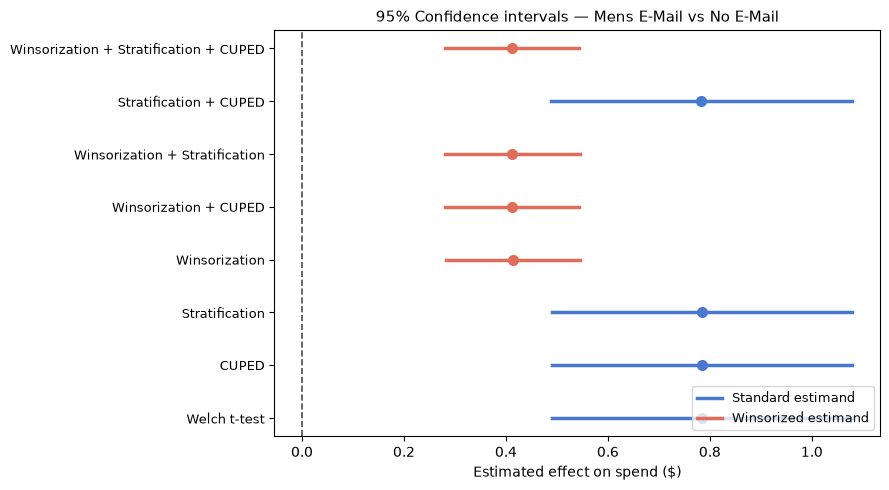

In [20]:
WINSORIZED_SET = {
    'Winsorization',
    'Winsorization + CUPED',
    'Winsorization + Stratification',
    'Winsorization + Stratification + CUPED',
}

method_names = list(mens_results.keys())
effects   = [mens_results[m]['effect']    for m in method_names]
ci_lowers = [mens_results[m]['ci_lower']  for m in method_names]
ci_uppers = [mens_results[m]['ci_upper']  for m in method_names]
colors    = ['#e06c5a' if m in WINSORIZED_SET else '#4878cf' for m in method_names]

fig, ax = plt.subplots(figsize=(9, 5))
y_positions = list(range(len(method_names)))

for i, (mname, eff, lo, hi, col) in enumerate(
        zip(method_names, effects, ci_lowers, ci_uppers, colors)):
    ax.plot([lo, hi], [i, i], color=col, lw=2.5)
    ax.plot(eff, i, 'o', color=col, markersize=7, zorder=3)

ax.axvline(0, color='black', lw=1.2, linestyle='--', alpha=0.7)
ax.set_yticks(y_positions)
ax.set_yticklabels(method_names, fontsize=9)
ax.set_xlabel('Estimated effect on spend ($)', fontsize=10)
ax.set_title('95% Confidence intervals — Mens E-Mail vs No E-Mail', fontsize=11)

from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='#4878cf', lw=2.5, label='Standard estimand'),
    Line2D([0], [0], color='#e06c5a', lw=2.5, label='Winsorized estimand'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
fig.tight_layout()
plt.show()

## Interpretation

### Predictiveness of history for CUPED

The correlation between prior purchase history and post-experiment spend
is positive and statistically significant in both groups
(see Cell 11 above for the exact values). Because CUPED's variance reduction
is proportional to the squared correlation between the covariate and the
outcome (variance reduction ≈ *r*²), a moderate positive correlation translates
into a meaningful reduction in the width of the 95% confidence interval.
The reported CUPED diagnostics confirm this: the adjusted variance of the
control group is visibly lower than the unadjusted variance, as reflected in
the reported `variance_reduction` percentages.

### Stratification by channel

Post-stratification by channel (`Web`, `Phone`, `Multichannel`) provides
additional precision improvements when the strata differ in both size and
mean outcome. The CI width comparison table shows whether stratification alone
reduces width relative to the Welch t-test baseline, and whether combining
it with CUPED yields further gains beyond either method individually.

### Effect of winsorization

Winsorization clips extreme observations at the 0.3th and 99.7th percentile
thresholds derived from the held-out calibration sample. Because the spend
distribution is heavily right-skewed with a mass at zero and a long right tail,
clipping the tail can substantially reduce variance, often yielding narrower
CIs than the raw Welch t-test. However, winsorization changes the *estimand*:
the estimated effect applies to the winsorized outcome, not the raw spend,
so effect estimates are not directly comparable across winsorized and
non-winsorized methods.

### Combined methods

The combination of winsorization, CUPED, and stratification
(`Winsorization + Stratification + CUPED`) is expected to achieve the narrowest
CI among the eight methods, since each component targets a different source of
variability. However, diminishing returns are possible when the gains from
individual components overlap (e.g., CUPED already accounts for much of the
history-driven heterogeneity captured by stratification).

### Statistical significance and consistency

Because this is a single historical experiment rather than a simulation, only
one realisation of the data is available. Whether the estimated effect crosses
the significance threshold depends on both the true effect size and the
precision of each estimator. The results table indicates which methods yield
a p-value below 0.05. Consistency across methods — i.e., whether all or most
methods agree on the sign and significance of the estimate — is informative
about the robustness of the finding.

### Calibration split

Using a held-out 20% sample of the No E-Mail group to compute winsorization
bounds prevents contamination of the analysis sample by calibration decisions.
The cost is a modest reduction in the effective control group size, which
slightly increases the SE relative to using the full control group. This
trade-off is standard practice and is clearly documented above.

### Note on estimands

Methods that apply winsorization target the average treatment effect on the
*winsorized* spend variable. This is a different quantity from the ATE on raw
spend. Results marked with `*` in the tables should be interpreted accordingly.
Precision comparisons (CI width reductions) are still meaningful within the
winsorized methods, but cross-group comparisons of effect *magnitudes* should
be made cautiously.